In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
data_dir = 'data'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 30  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 4982 images belonging to 8 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1242 images belonging to 8 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)
print(f"Class labels: {class_labels}")
print(f"Number of classes: {num_classes}")
print(f"Class counts: {class_counts}")

Class labels: ['Blend', 'Denim', 'NaturalFibers', 'Other', 'Smooth', 'SyntheticFibers', 'Textured', 'Unclassified']
Number of classes: 8
Class counts: [  96  519 2391   74  160 1060  288  394]


In [7]:
from collections import Counter

counter = Counter(train_generator.classes)
max_count = float(max(counter.values()))
class_weights = {class_id: max_count / count for class_id, count in counter.items()}
print(class_weights)

{np.int32(0): 24.90625, np.int32(1): 4.606936416184971, np.int32(2): 1.0, np.int32(3): 32.310810810810814, np.int32(4): 14.94375, np.int32(5): 2.2556603773584905, np.int32(6): 8.302083333333334, np.int32(7): 6.068527918781726}


In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [11]:
model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Stop after 10 epochs of no improvement
    min_delta=0.001,        # Minimum change to be considered an improvement
    mode='min',             # We want the validation loss to minimize
    verbose=1,              # Print a message when it stops
    restore_best_weights=True # Restore model weights from the epoch with the best val_loss
)

class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, accuracy_threshold=0.90, val_accuracy_threshold=0.90):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.val_accuracy_threshold = val_accuracy_threshold
        print(f"Accuracy Threshold Callback initialized: Train Acc >= {accuracy_threshold*100}% OR Val Acc >= {val_accuracy_threshold*100}%")

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is None or current_val_acc is None:
            print("Warning: 'accuracy' or 'val_accuracy' not found in logs. Cannot check thresholds.")
            return

        if current_acc >= self.accuracy_threshold or current_val_acc >= self.val_accuracy_threshold:
            print(f"\nEpoch {epoch+1}: Reached desired accuracy threshold!")
            print(f"  Train Acc: {current_acc:.4f}, Val Acc: {current_val_acc:.4f}")
            self.model.stop_training = True

In [14]:
my_callbacks = [
    AccuracyThresholdCallback(accuracy_threshold=0.90, val_accuracy_threshold=0.90),
    early_stopping_callback
]

Accuracy Threshold Callback initialized: Train Acc >= 90.0% OR Val Acc >= 90.0%


In [15]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,  
    verbose=1,
    class_weight=class_weights,
    callbacks=my_callbacks
)

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.3285 - loss: 6.3831 - val_accuracy: 0.5271 - val_loss: 1.2601
Epoch 2/30
  1/155 ━━━━━━━━━━━━━━━━━━━━ 1:31 594ms/step - accuracy: 0.4688 - loss: 6.1320

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


155/155 ━━━━━━━━━━━━━━━━━━━━ 45s 286ms/step - accuracy: 0.4688 - loss: 6.1320 - val_accuracy: 0.5617 - val_loss: 1.2194
Epoch 3/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.5161 - loss: 3.7891 - val_accuracy: 0.5822 - val_loss: 1.1313
Epoch 4/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 45s 288ms/step - accuracy: 0.5000 - loss: 2.2894 - val_accuracy: 0.6003 - val_loss: 1.1283
Epoch 5/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.5720 - loss: 3.2948 - val_accuracy: 0.6086 - val_loss: 1.0678
Epoch 6/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 50s 323ms/step - accuracy: 0.5312 - loss: 3.8046 - val_accuracy: 0.6110 - val_loss: 1.0829
Epoch 7/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.5863 - loss: 2.9767 - val_accuracy: 0.6620 - val_loss: 0.9517
Epoch 8/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 50s 319ms/step - accuracy: 0.6562 - loss: 2.2109 - val_accuracy: 0.6332 - val_loss: 1.0083
Epoch 9/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.6051 - loss: 2.8193 - val_accurac

In [16]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7272 - loss: 0.6928
Validation Loss: 0.7579
Validation Accuracy: 0.7122


In [17]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs found:", gpus)
    try:
        # Set TensorFlow to use a specific GPU (optional, if you have multiple)
        # tf.config.set_visible_devices(gpus[0], 'GPU')
        # Allow dynamic memory allocation (important to avoid out-of-memory errors)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth set to True.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPUs found. TensorFlow will run on CPU.")

No GPUs found. TensorFlow will run on CPU.


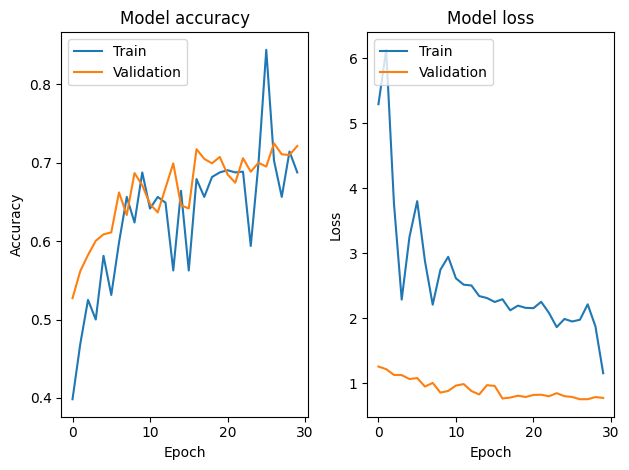

In [19]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
model.save('models/fabric_texture_model_3.h5')

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
model_path = "models/fabric_texture_model_3.h5"
model_1 = tf.keras.models.load_model(model_path)

In [23]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes

Making predictions on the validation set...
39/39 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step


In [24]:
class_names = list(validation_generator.class_indices.keys())
print("\n--- Classification Report ---")
# target_names: provides meaningful labels for the report
# digits: number of decimal places for floating point values
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


--- Classification Report ---
                 precision    recall  f1-score   support

          Blend     0.6765    0.9583    0.7931        24
          Denim     0.7468    0.8915    0.8127       129
  NaturalFibers     0.9185    0.6231    0.7425       597
          Other     0.3208    0.9444    0.4789        18
         Smooth     0.4085    0.7250    0.5225        40
SyntheticFibers     0.6409    0.8182    0.7188       264
       Textured     0.6566    0.9028    0.7602        72
   Unclassified     0.7416    0.6735    0.7059        98

       accuracy                         0.7271      1242
      macro avg     0.6388    0.8171    0.6918      1242
   weighted avg     0.7828    0.7271    0.7330      1242



In [25]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


--- Confusion Matrix ---
[[ 23   0   1   0   0   0   0   0]
 [  0 115   7   0   1   4   1   1]
 [ 10  35 372  21  30  95  20  14]
 [  0   0   0  17   0   0   0   1]
 [  0   0   0   1  29   9   0   1]
 [  0   3  18   7   8 216   8   4]
 [  1   0   0   1   1   2  65   2]
 [  0   1   7   6   2  11   5  66]]


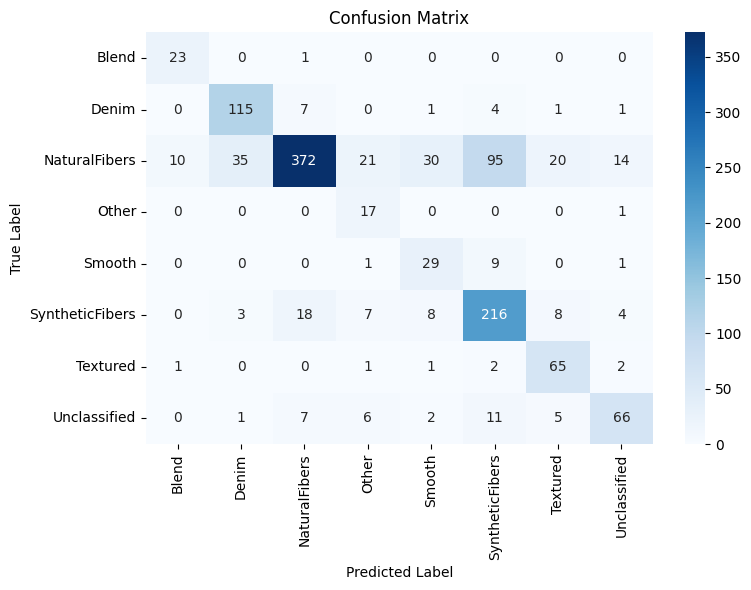

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# model 2

In [ ]:
from tensorflow.keras.layers import Dropout
x_2 = base_model.output
x_2 = GlobalAveragePooling2D()(x_2)
x_2 = Dense(1024, activation='relu')(x_2)
#x_2 = x = Dropout(0.5)(x)
predictions_2 = Dense(num_classes, activation='softmax')(x_2)

In [ ]:
model_2 = Model(inputs=base_model.input, outputs=predictions_2)

In [ ]:
optimizer_2 = tf.keras.optimizers.Adam(learning_rate=0.00005)  # Adjust learning rate as needed
model_2.compile(optimizer=optimizer_2, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_2 = model_2.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,  
    verbose=1,
    class_weight=class_weights
)